# Dados do aluno

##### **Nome**: Breno Maciel de Assis
##### **RGM**: 11241101614
##### **Curso**: Engenharia de Software
##### **Período**: 6ºA | Matutino
##### **Professor**: Fabiano Bezerra Menegidio

---
# Sumário
#### 1. Imports das bibliotecas
#### 2. Carregando o dataset
#### 3. Análise Exploratória
#### 4. Definindo entradas e saídas
#### 5. Separando os dados de treino e de teste
#### 6. Experimento 1 - Testando o SVM linear
#### 7. Validação cruzada do SVM linear
#### 8. Experimento 2 - Testando o SVM não linear (com kernel RBF)
#### 9. Validação cruzada do SVM não linear (com kernel RBF)
#### 10. Comparação dos modelos testados

---
# 1. Importando as bibliotecas
Primeiramente, importo as bibliotecas necessárias para carregar o dataset, manipular os dados, dividir os dados de treino e teste, padronizar variáveis, treinar os modelos SVM, calcular métricas e produzir gráficos e matrizes de confusão.

In [83]:
import kagglehub 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import os

for dirname, _, filenames in os.walk('/kaggle/input/datasets/menegidio/iris-species'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

plt.rcParams['figure.figsize'] = (8, 5)
df = pd.read_csv('/kaggle/input/datasets/menegidio/iris-species/Iris.csv')
df.head()

/kaggle/input/datasets/menegidio/iris-species/Iris.csv
/kaggle/input/datasets/menegidio/iris-species/database.sqlite


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


---
# 2. Carregando devidamente o dataset
Então, eu carrego o dataset Iris na variável 'iris', armazeno na variável 'X' o valor das características das amostras, e na variável 'y' os rótulos.

Logo na variável 'species_names', armazeno os nomes das espécies das amostras coletadas. Defino na variável 'df' a cópia atual do DataFrame das características, e relaciono a coluna 'species_id' com o y (que contém os conteúdos de rótulo das amostras).

Também defino 'species' como a nossa variável-alvo (a que mostrará o resultado aparente), e a faço retornar o nome da espécie de acordo com seu respectivo id (da 'species_id', mapeando em relação ao 'species_names').

Por fim, retorno as primeiras 5 linhas do dataframe.

In [84]:
iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='species_id')

species_names = {i: name for i, name in enumerate(iris.target_names)}
feature_names = list(iris.feature_names)

df = X.copy()
df["species_id"] = y
df["species"] = df["species_id"].map(species_names)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


Apresento a dimensão do dataset, assim como os nomes das nossas variáveis, a contagem de amostras por espécie, e a descrição estatística dos dados.

In [85]:
print(f"Dimensão do dataset: {df.shape}")
print("\nNomes das colunas:")
for col in df.columns:
    print(f"-{col}")

print("\nContagem por espécie:")
print(df["species"].value_counts())

print("\nDescrição estatística:")
df.describe()

Dimensão do dataset: (150, 6)

Nomes das colunas:
-sepal length (cm)
-sepal width (cm)
-petal length (cm)
-petal width (cm)
-species_id
-species

Contagem por espécie:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Descrição estatística:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


---
# 3. Análise Exploratória de Dados (EDA)
A Análise Exploratória de Dados (EDA) consiste na validação da integridade estrutural dos dados, verificação do balanceamento do vetor de respostas (para garantir que não haja algum viés), entendimento das distribuições estatísticas aplicadas nos dados e análise gráfica da separabilidade espacial entre as classes das amostras.

In [112]:
print("---VERIFICAÇÃO DE VALORES NULOS---")
print(df.isnull().sum())

---VERIFICAÇÃO DE VALORES NULOS---
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species_id           0
species              0
dtype: int64


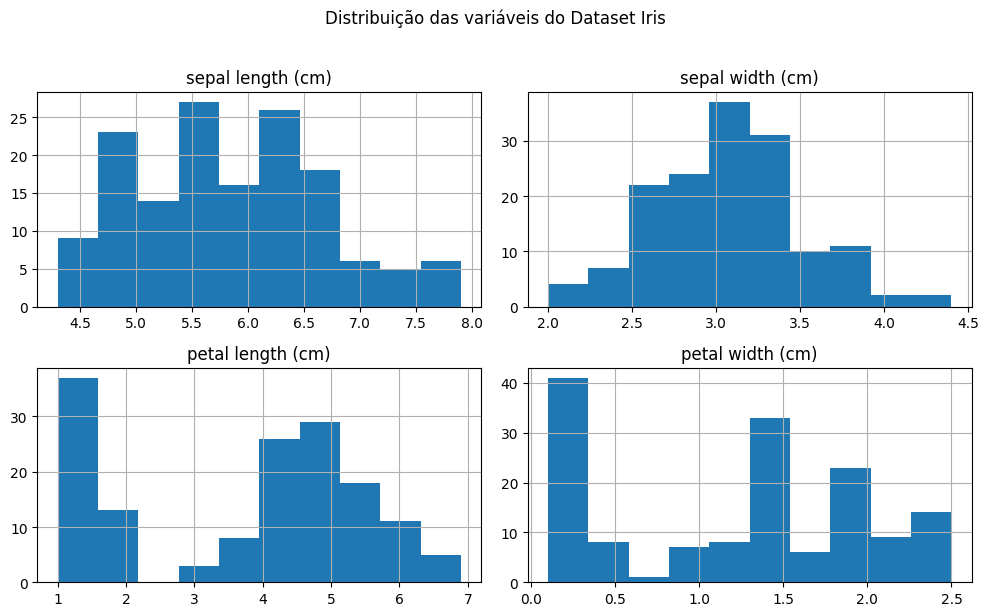

In [87]:
df[X.columns].hist(figsize=(10, 6))
plt.suptitle("Distribuição das variáveis do Dataset Iris", y=1.02)
plt.tight_layout()
plt.show()

Então, utilizo os 'scatter plots' para cruzar os pares das variáveis, para poder visualizar como os pontos de cada espécie da amostra se distribuem no plano.

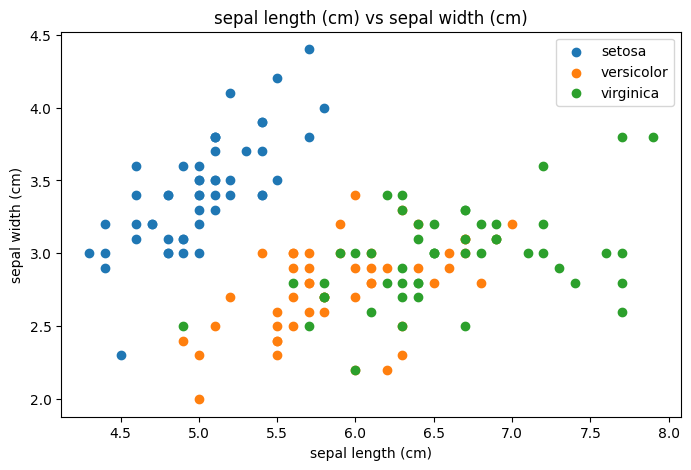

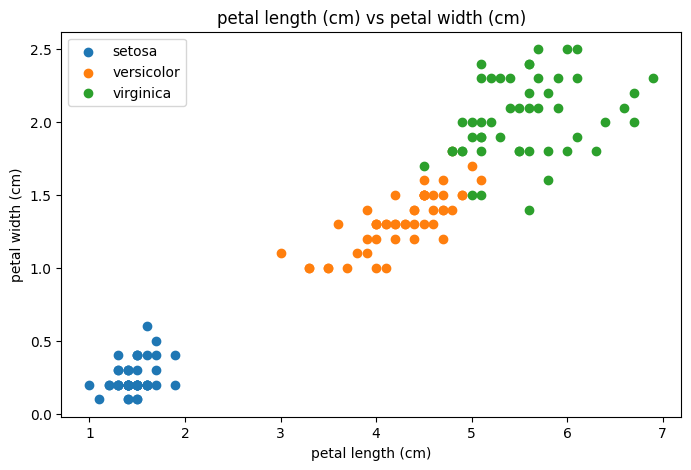

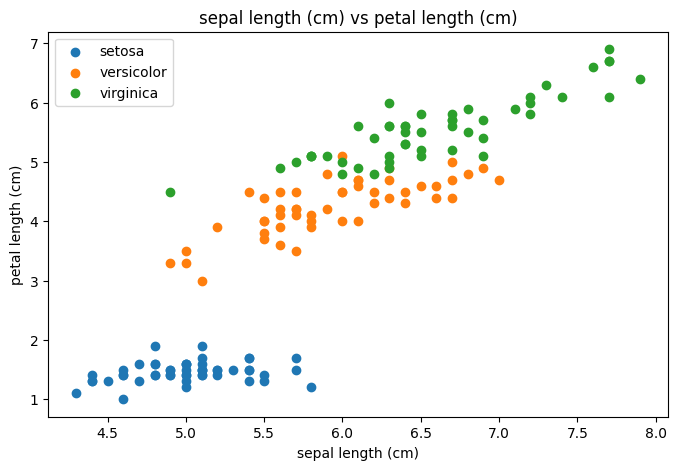

In [88]:
pairs = [
    ("sepal length (cm)", "sepal width (cm)"),
    ("petal length (cm)", "petal width (cm)"),
    ("sepal length (cm)", "petal length (cm)")
]

for xcol, ycol in pairs:
    plt.figure()
    for species in df["species"].unique():
        subset = df[df["species"] == species]
        plt.scatter(subset[xcol], subset[ycol], label=species)
    plt.xlabel(xcol)
    plt.ylabel(ycol)
    plt.title(f"{xcol} vs {ycol}")
    plt.legend()
    plt.show()

---
# 4. Definindo a matriz de atributos (X) e o vetor de rótulos (y)
A seguir, defino a matriz com as medidas das pétalas e sépalas das flores na variável 'X', e um vetor com a espécie relativa de cada amostra na variável 'y'.

In [89]:
X = df[iris.feature_names]
y = df["species"]

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (150, 4)
Formato de y: (150,)


---
# 5. Separando os dados de treino e de teste
Em seguida, eu separo os dados de treino e os dados de teste na proporção de 80% para treino e 20% para testes.

In [100]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Amostras de Treino (X_train):", X_train.shape)
print("Amostras de Teste (X_test):", X_test.shape)

print("\nDistribuição no conjunto de Treino (y_train):")
print(y_train.value_counts())
print("\nDistribuição no conjunto de Teste (y_test):")
print(y_test.value_counts())

Amostras de Treino (X_train): (120, 4)
Amostras de Teste (X_test): (30, 4)

Distribuição no conjunto de Treino (y_train):
species
setosa        40
virginica     40
versicolor    40
Name: count, dtype: int64

Distribuição no conjunto de Teste (y_test):
species
setosa        10
virginica     10
versicolor    10
Name: count, dtype: int64


---
# 6. Experimento 1 - Testando o SVM linear
O SVM linear é um modelo simples que busca separar as classes maximizando a distância entre elas e os pontos mais próximos de cada classe (que são chamados de vetores de suporte)

In [101]:
pipeline_svm_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1.0, random_state=42))
])

pipeline_svm_linear.fit(X_train, y_train)

y_pred_linear = pipeline_svm_linear.predict(X_test)

acc_linear = accuracy_score(y_test, y_pred_linear)
print(f"Acurácia do SVM linear: {acc_linear:.4f} ({acc_linear*100:.1f}%)")

Acurácia do SVM linear: 1.0000 (100.0%)


In [92]:
print("Relatório de classificação - SVM linear\n")
print(classification_report(y_test, y_pred_linear))

Relatório de classificação — SVM linear

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



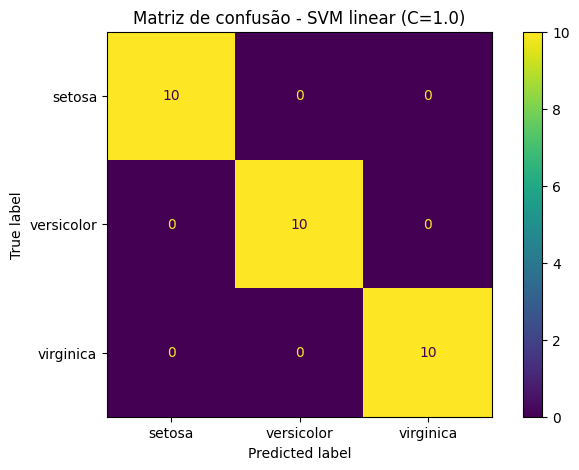

In [102]:
cm_linear = confusion_matrix(y_test, y_pred_linear, labels=iris.target_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_linear, display_labels=iris.target_names)
disp.plot()
plt.title("Matriz de confusão - SVM linear (C=1.0)")
plt.show()

---
# 7. Validação cruzada do SVM linear
A validação cruzada divide o dataset em partes proporcionais (folds) para que os resultados não tenham sido por sorte do conjunto de testes, neste caso, vou usar 5 folds (sendo o valor do meu CV).

In [110]:
scores_linear = cross_val_score(pipeline_svm_linear, X, y, cv=5)

print("Acurácia em cada fold:", scores_linear)
print(f"Média: {scores_linear.mean():.4f} ({scores_linear.mean()*100:.1f}%)")
print(f"Desvio-padrão: {scores_linear.std():.4f}")

Acurácia em cada fold: [0.96666667 1.         0.93333333 0.93333333 1.        ]
Média: 0.9667 (96.7%)
Desvio-padrão: 0.0298


---
# 8. Experimento 2 - SVM não linear (com kernel RBF)
Para o SVM não linear, vou utilizar do kernel RBF, que utiliza do Kernel Trick para mapear, implicitamente, os dados para um espaço de dimensão superior, onde uma linha que separe as classes possa ser construída. Em seguida, retorno o relatório de classificação do SVM.

In [103]:
pipeline_svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
])

pipeline_svm_rbf.fit(X_train, y_train)

y_pred_rbf = pipeline_svm_rbf.predict(X_test)

acc_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"Acurácia do SVM com kernel RBF: {acc_rbf:.4f} ({acc_rbf*100:.1f}%)")

Acurácia do SVM com kernel RBF: 0.9667 (96.7%)


In [96]:
print("Relatório de classificação — SVM com kernel RBF\n")
print(classification_report(y_test, y_pred_rbf))

Relatório de classificação — SVM com kernel RBF

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



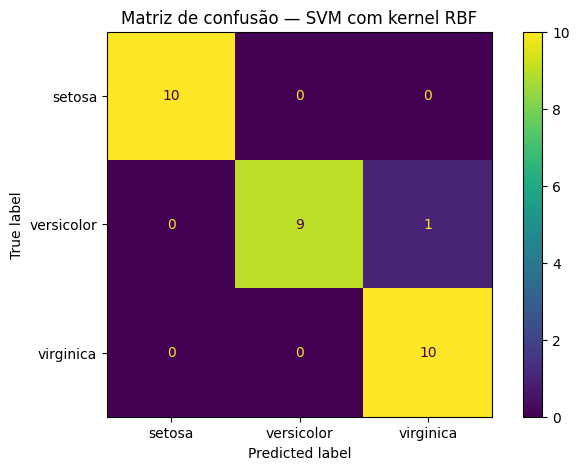

In [97]:
cm_rbf = confusion_matrix(y_test, y_pred_rbf, labels=iris.target_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rbf, display_labels=iris.target_names)
disp.plot()
plt.title("Matriz de confusão — SVM com kernel RBF")
plt.show()

---
# 9. Validação cruzada do SVM (com kernel RBF)
Ainda utilizando o CV em 5, a validação cruzada do SVM com o kernel RBF verifica a estabilidade preditiva nas diferentes partes proporcionais do dataset, e comparando diretamente com o SVM linear.

In [109]:
scores_rbf = cross_val_score(pipeline_svm_rbf, X, y, cv=5)

print("Acurácia em cada fold:", scores_rbf)
print(f"Acurácia média CV: {scores_rbf.mean():.4f} ({scores_rbf.mean()*100:.1f}%)")
print(f"Desvio-padrão CV: {scores_rbf.std():.4f}")

Acurácia em cada fold: [0.96666667 0.96666667 0.96666667 0.93333333 1.        ]
Acurácia média CV: 0.9667 (96.7%)
Desvio-padrão CV: 0.0211


---
# 10. Comparação entre os modelos
Agora, eu comparo o modelo do SVM Linear e do SVM Não Linear com o uso do RBF.

In [99]:
comparacao = pd.DataFrame({
    "Modelo": ["SVM linear", "SVM não linear (RBF)"],
    "Acurácia no teste": [acc_linear, acc_rbf],
    "Acurácia média CV": [scores_linear.mean(), scores_rbf.mean()],
    "Desvio-padrão CV": [scores_linear.std(), scores_rbf.std()]
})

comparacao

,Modelo,Acurácia no teste,Acurácia média CV,Desvio-padrão CV
0,SVM linear,1.000000,0.966667,0.029814
1,SVM não linear (RBF),0.966667,0.966667,0.021082


Em suma, ambos os modelos apresentam um ótimo desempenho, e é perceptível que possuem a mesma acurácia média do CV. Contudo, o modelo ideal a ser escolhido, neste caso, é o modelo que preserva de modo mais econômico os recursos computacionais, que é o SVM linear.